Import libraries & Dataset Load

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)


df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Initial Inspection

In [4]:

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Univariate Analysis

In [5]:
survival_rate = df["Survived"].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


Survival Distribution

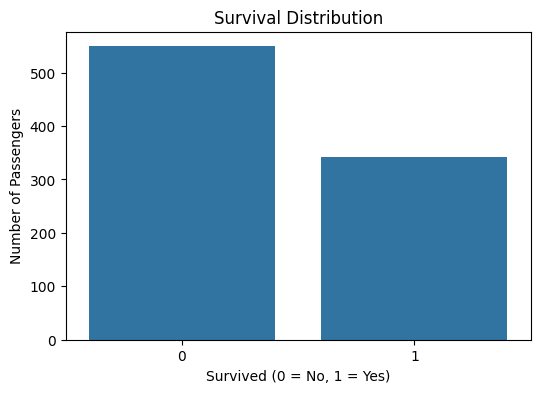

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

Passenger Class Distribution

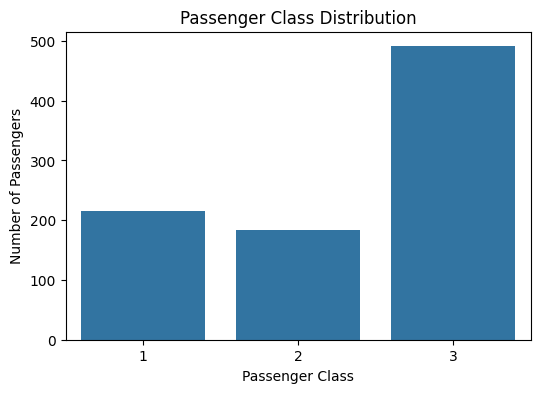

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Highest value

In [8]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


Bivariate & Multivariate Analysis

In [9]:
sex_survival = pd.crosstab(df["Sex"], df["Survived"])

sex_survival

Survived,0,1
Sex,,
female,81,233
male,468,109


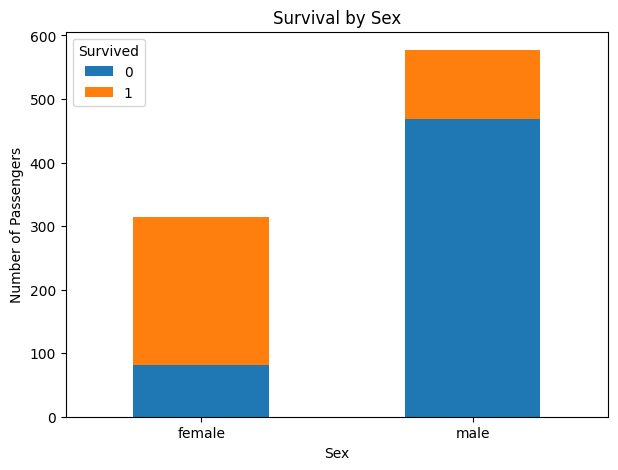

In [10]:
sex_survival.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.show()

In [11]:
sex_survival_rate = df.groupby("Sex")["Survived"].mean() * 100

print(sex_survival_rate)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


Female passengers had a significantly higher survival rate than male passengers.

Survival by Pclass

In [13]:
class_survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival_rate)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


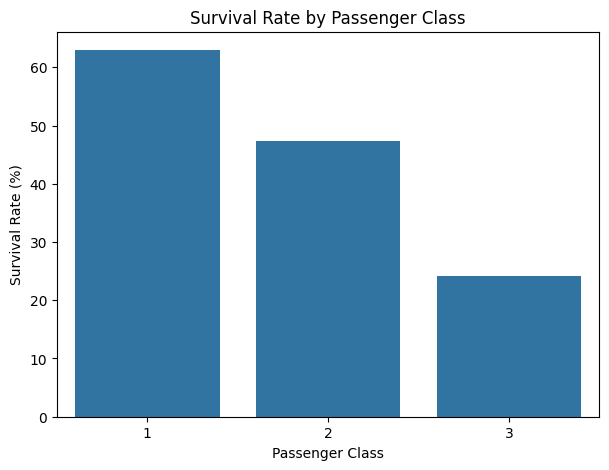

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=class_survival_rate.index,
    y=class_survival_rate.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

Yes. There is a clear relationship between ticket class and survival probability. First-class passengers had the highest survival rate, while third-class passengers had the lowest.

Survival by Age

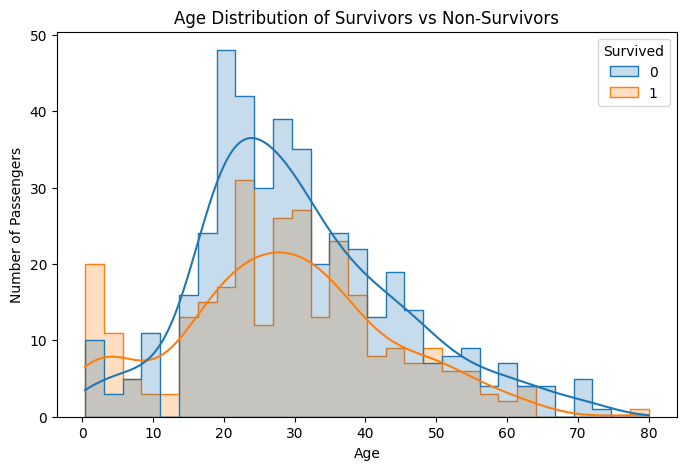

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution of Survivors vs Non-Survivors")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Observation

The age distribution suggests that children had relatively better survival chances, while older passengers generally had lower survival chances. However, age alone was not as strong a factor as gender and passenger class.

Survival by Embarkation Port

In [16]:
embarked_survival_rate = df.groupby("Embarked")["Survived"].mean() * 100

print(embarked_survival_rate)

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


Visualization

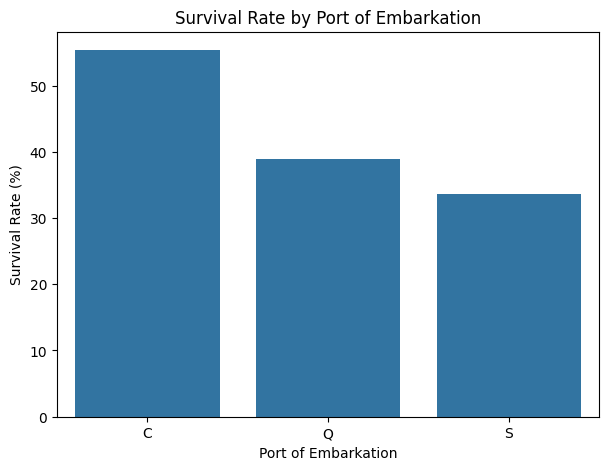

In [17]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=embarked_survival_rate.index,
    y=embarked_survival_rate.values
)

plt.title("Survival Rate by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate (%)")

plt.show()

Conclusion

The EDA shows that gender and passenger class were the strongest factors associated with survival on the Titanic. Female passengers had a significantly higher survival rate than male passengers, while first-class passengers were more likely to survive than those in second or third class. Age also influenced survival, with children showing relatively better survival chances than many older passengers. Overall, Sex, Pclass, and Age appear to be the most important features affecting passenger survival.